## Import Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.preprocessing import StandardScaler                                               
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve      
from pathlib import Path
from joblib import dump

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset
from torchmetrics.classification import BinaryPrecision, BinaryRecall, BinaryAUROC, BinaryAveragePrecision, BinaryF1Score
import pytorch_lightning as pl
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint

In [4]:
torch.set_float32_matmul_precision('medium')

## Import Datasets

In [5]:
lead_time = 1
base_dir = Path(f'/gws/nopw/j04/wiser_ewsa/mrakotomanga/EPS/Data/Zambia/64x64/full/timesteps/t{lead_time}')

In [6]:
train_data_X = pd.read_csv(base_dir / f'train-zambia-input-t0-for-lt{lead_time}.csv')
train_data_y_t = np.load(base_dir / f'train-zambia-output-at-lt{lead_time}.npy')

test_data_X = pd.read_csv(base_dir / f'test-zambia-input-t0-for-lt{lead_time}.csv')
test_data_y_t = np.load(base_dir / f'test-zambia-output-at-lt{lead_time}.npy')

train_data_X, val_data_X, train_data_y_t, val_data_y_t = train_test_split(train_data_X, train_data_y_t, test_size=0.3, random_state=12)

### Log transforming

In [11]:
train_data_X

,year,month,day,hour,minute,lat1,lat2,lon1,lon2,wp1,...,lon1_120,lon2_120,wp1_120,wp2_120,size1_120,size2_120,d1_120,d2_120,mask1_120,mask2_120
90691,2015,12,17,16,15,-13.504042,-14.577767,25.613913,25.701277,155.014851,...,24.761513,31.056561,95.567164,114.704545,1206.0,792.0,394.589579,452.723801,1.0,1.0
51778,2010,12,15,20,0,-13.489795,-16.148860,23.417059,24.138006,104.142857,...,29.964275,30.827269,124.532609,138.485795,828.0,3168.0,581.592184,697.741874,1.0,1.0
95659,2016,2,9,8,45,-5.902881,-4.847446,20.930325,20.434313,111.533333,...,28.227720,25.744390,128.769231,136.500000,117.0,162.0,186.763400,266.650519,1.0,1.0
28113,2007,12,9,22,0,-16.366394,-16.434498,27.027290,32.647953,90.538462,...,27.626579,34.130901,141.750000,110.795918,1476.0,441.0,489.757488,1012.586603,1.0,1.0
115377,2018,12,27,8,45,-1.600589,3.497482,23.142965,19.561534,104.383764,...,27.647120,26.363974,102.769231,131.743590,117.0,351.0,54.085323,228.483288,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36482,2008,12,30,1,15,-12.603001,-11.094649,30.795670,30.292500,179.614786,...,29.842611,31.557623,111.115385,184.458613,234.0,4023.0,292.300222,385.661568,1.0,1.0
40177,2009,2,7,1,15,-7.556831,-8.164921,31.720074,32.561657,105.000000,...,22.456841,18.351503,126.666667,140.668269,162.0,1872.0,989.994561,1077.248594,1.0,1.0
19709,2006,12,7,19,45,-13.483546,-14.798624,31.225462,19.259024,125.360000,...,31.007326,19.098368,112.272727,175.073333,198.0,1350.0,338.923834,967.295526,1.0,1.0
104091,2017,2,16,19,0,-13.395371,-11.917105,29.945415,29.751926,138.163032,...,29.192818,30.345457,122.433824,99.902439,1224.0,369.0,161.372549,281.662338,1.0,1.0


In [12]:
# Log transform
suffixes = ['', '_60', '_120']
prefixes = ['size', 'wp', 'd']
indices = ['1', '2']
cols_to_log = [f'{prefix}{i}{suf}' for suf in suffixes for prefix in prefixes for i in indices]

for col in cols_to_log:
    for df in [train_data_X, test_data_X, val_data_X]:
        df[col] = np.log1p(df[col].astype(float))

### Scaling

In [14]:
# Exclude all columns that start with 'mask'
mask_cols = [col for col in train_data_X.columns if col.startswith('mask')]

# Final list of features to scale
cols_to_scale = [col for col in train_data_X.columns if col not in mask_cols]

# Initialise scaler
scaler = StandardScaler()

# Apply scaling
X_train_scaled = train_data_X.copy()
X_train_scaled[cols_to_scale] = scaler.fit_transform(train_data_X[cols_to_scale])

X_val_scaled = val_data_X.copy()
X_val_scaled[cols_to_scale] = scaler.transform(val_data_X[cols_to_scale])

X_test_scaled = test_data_X.copy()
X_test_scaled[cols_to_scale] = scaler.transform(test_data_X[cols_to_scale])

In [15]:
X_test_scaled.keys()

Index(['year', 'month', 'day', 'hour', 'minute', 'lat1', 'lat2', 'lon1',
       'lon2', 'wp1', 'wp2', 'size1', 'size2', 'd1', 'd2', 'mask1', 'mask2',
       'year_60', 'month_60', 'day_60', 'hour_60', 'minute_60', 'lat1_60',
       'lat2_60', 'lon1_60', 'lon2_60', 'wp1_60', 'wp2_60', 'size1_60',
       'size2_60', 'd1_60', 'd2_60', 'mask1_60', 'mask2_60', 'year_120',
       'month_120', 'day_120', 'hour_120', 'minute_120', 'lat1_120',
       'lat2_120', 'lon1_120', 'lon2_120', 'wp1_120', 'wp2_120', 'size1_120',
       'size2_120', 'd1_120', 'd2_120', 'mask1_120', 'mask2_120'],
      dtype='object')

In [17]:
assert X_test_scaled.shape[1] == X_train_scaled.shape[1] == 3 * 17 # expect 3 time steps of 17 features

In [16]:
num_time_steps = 3
num_features = 17

# Reshape
x_train = X_train_scaled.values.reshape(len(train_data_y_t), num_time_steps, num_features)
x_val = X_val_scaled.values.reshape(len(val_data_y_t), num_time_steps, num_features)
x_test = X_test_scaled.values.reshape(len(test_data_y_t), num_time_steps, num_features)

In [22]:
# PyTorch model
class LightLSTMToConv64(nn.Module):
    def __init__(self, input_size=17, hidden_sizes=[64, 32], initial_size=4):
        super().__init__()
        self.initial_size = initial_size
        self.lstm1 = nn.LSTM(input_size=input_size, hidden_size=hidden_sizes[0], batch_first=True)
        self.lstm2 = nn.LSTM(input_size=hidden_sizes[0], hidden_size=hidden_sizes[1], batch_first=True)
        self.fc = nn.Linear(hidden_sizes[1], initial_size * initial_size * 8)
        self.relu = nn.ReLU()
        self.conv1 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(8, 4, kernel_size=3, padding=1)
        self.out_conv = nn.Conv2d(4, 1, kernel_size=1)

    def forward(self, x):
        x, _ = self.lstm1(x)
        x, _ = self.lstm2(x)
        x = self.relu(self.fc(x[:, -1]))
        x = x.view(-1, 8, self.initial_size, self.initial_size)
        x = F.interpolate(x, scale_factor=2)
        x = self.relu(self.conv1(x))
        x = F.interpolate(x, scale_factor=2)
        x = self.relu(self.conv2(x))
        x = F.interpolate(x, scale_factor=2)
        x = self.relu(self.conv3(x))
        x = F.interpolate(x, scale_factor=2)
        return torch.sigmoid(self.out_conv(x))

# Lightning module
class LightningUpsampleModel(pl.LightningModule):
    def __init__(self, input_dim=17, lr=1e-3, threshold=0.15):
        super().__init__()
        self.save_hyperparameters()
        self.model = LightLSTMToConv64(input_size=input_dim)
        self.criterion = nn.BCELoss()
        self.precision = BinaryPrecision(threshold=threshold)
        self.recall = BinaryRecall(threshold=threshold)
        self.f1 = BinaryF1Score(threshold=threshold)
        self.auc = BinaryAUROC()
        self.prc = BinaryAveragePrecision()

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        self.log('train_loss', loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self.forward(x)
        y = y.long()  # convert from float32 to int (0 or 1)

        loss = self.criterion(y_hat, y.float())  # BCE loss still needs float
        self.log("val_loss", loss)

        # For metrics
        self.precision.update(y_hat.view(-1), y.view(-1))
        self.recall.update(y_hat.view(-1), y.view(-1))
        self.f1.update(y_hat.view(-1), y.view(-1))
        self.auc.update(y_hat.view(-1), y.view(-1))
        self.prc.update(y_hat.view(-1), y.view(-1))
        return loss

    def on_validation_epoch_end(self):
        self.log('val_precision', self.precision.compute(), prog_bar=True)
        self.log('val_recall', self.recall.compute(), prog_bar=True)
        self.log('val_f1', self.f1.compute(), prog_bar=True)
        self.log('val_auc', self.auc.compute(), prog_bar=True)
        self.log('val_prc', self.prc.compute(), prog_bar=True)
        for metric in [self.precision, self.recall, self.f1, self.auc, self.prc]:
            metric.reset()

    def configure_optimizers(self):
        return Adam(self.parameters(), lr=self.hparams.lr)

# Preparing datasets

In [19]:
y_train_tensor = torch.from_numpy(train_data_y_t).float().unsqueeze(1)
y_val_tensor = torch.from_numpy(val_data_y_t).float().unsqueeze(1)
y_test_tensor = torch.from_numpy(test_data_y_t).float().unsqueeze(1)

train_loader = DataLoader(TensorDataset(torch.from_numpy(x_train).float(), y_train_tensor), batch_size=16, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.from_numpy(x_val).float(), y_val_tensor), batch_size=16)

# Training

In [23]:
model = LightningUpsampleModel()
trainer = Trainer(accelerator='auto', devices=1, max_epochs=2,
                  callbacks=[EarlyStopping(monitor='val_loss', patience=3),
                             ModelCheckpoint(monitor='val_loss', save_top_k=1)],
                  log_every_n_steps=5)

trainer.fit(model, train_loader, val_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]

  | Name      | Type                   | Params | Mode 
-------------------------------------------------------------
0 | model     | LightLSTMToConv64      | 40.6 K | train
1 | criterion | BCELoss                | 0      | train
2 | precision | BinaryPrecision        | 0      | train
3 | recall    | BinaryRecall           | 0      | train
4 | f1        | BinaryF1Score          | 0      | train
5 | auc       | BinaryAUROC            | 0      | train
6 | prc       | BinaryAveragePrecision | 0      | train
-------------------------------------------------------------
40.6 K    Trainable params
0         Non-trainable params
40.6 K    Total params
0.163     Total estimated model params size (MB)
15        Modules in train mode
0         Modules in eval mode


/home/users/mendrika/EPS-Impact-Case-AI-Nowcasting/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 1: 100%|██████████| 5404/5404 [01:00<00:00, 88.77it/s, v_num=18, train_loss=0.0572, val_precision=0.242, val_recall=0.00771, val_f1=0.0149, val_auc=0.830, val_prc=0.0599]  

`Trainer.fit` stopped: `max_epochs=2` reached.


Epoch 1: 100%|██████████| 5404/5404 [01:00<00:00, 88.65it/s, v_num=18, train_loss=0.0572, val_precision=0.242, val_recall=0.00771, val_f1=0.0149, val_auc=0.830, val_prc=0.0599]


# Evaluation

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device).eval()

def batched_predict(x):
    loader = DataLoader(TensorDataset(torch.from_numpy(x).float()), batch_size=64)
    preds = []
    with torch.no_grad():
        for batch in loader:
            preds.append(model(batch[0].to(device)).cpu())
    return torch.cat(preds).numpy().flatten()

pred_y_train = batched_predict(x_train)
pred_y_test = batched_predict(x_test)

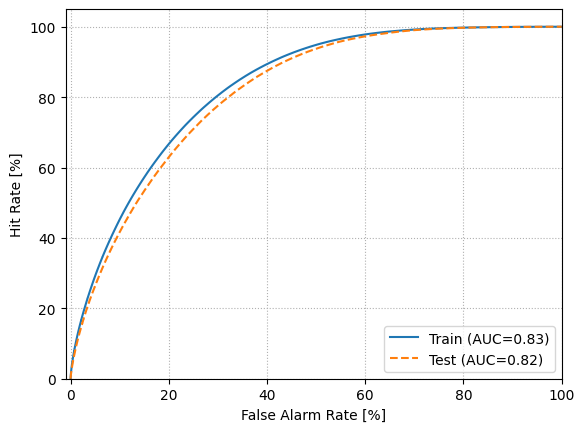

In [26]:
def plot_roc(name, y_true, y_pred, **kwargs):
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    plt.plot(100 * fpr, 100 * tpr, label=name, **kwargs)
    plt.xlabel("False Alarm Rate [%]")
    plt.ylabel("Hit Rate [%]")
    plt.xlim([-1, 100])
    plt.ylim([0, 105])
    plt.grid(True, linestyle=':')
    plt.legend(loc='lower right')
    plt.savefig('/home/users/mendrika/EPS-Impact-Case-AI-Nowcasting/model/zambia/roc-lead-time-1.png')

auc_train = roc_auc_score(train_data_y_t.flatten(), pred_y_train)
auc_test = roc_auc_score(test_data_y_t.flatten(), pred_y_test)

plot_roc(f"Train (AUC={auc_train:.2f})", train_data_y_t.flatten(), pred_y_train)
plot_roc(f"Test (AUC={auc_test:.2f})", test_data_y_t.flatten(), pred_y_test, linestyle="--")
plt.show()

### Reliability diagram

In [27]:
model_save_path = Path(f'/home/users/mendrika/EPS-Impact-Case-AI-Nowcasting/model/zambia/lead-time-{lead_time}h/saved')                       
model_weights = f'zambia-model-multi-timesteps-64x64-t{lead_time}.pth'
model_scaler = f'zambia-model-multi-timesteps-64x64-t{lead_time}.bin'

dump(scaler, model_save_path/model_scaler)
torch.save(model.state_dict(), model_save_path/model_weights)